<a href="https://colab.research.google.com/github/Rapolu-Sri-Sanchali/NASSCOM/blob/main/U6_Probability_Statistics_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [8]:
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls
p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')


P(even) ~ 0.499  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [9]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')



P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [11]:
flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)   # number of heads in each pair: 0, 1 or 2

# 1. P(both heads)  -> heads == 2
p_both_heads = (heads == 2).mean()
print(f"P(both heads) = {p_both_heads:.3f}")

# 2. P(at least one head)  -> heads >= 1
p_at_least_one_head = (heads >= 1).mean()
print(f"P(at least one head) = {p_at_least_one_head:.3f}")

# 3. Do P(0) + P(1) + P(2) sum to 1?
p_0_heads = (heads == 0).mean()
p_1_head = (heads == 1).mean()
p_2_heads = (heads == 2).mean()
sum_probabilities = p_0_heads + p_1_head + p_2_heads
print(f"P(0) + P(1) + P(2) = {sum_probabilities:.3f} -> {'they sum to 1' if abs(sum_probabilities - 1) < 1e-6 else 'they do not sum to 1'}")

P(both heads) = 0.249
P(at least one head) = 0.749
P(0) + P(1) + P(2) = 1.000 -> they sum to 1


In [13]:
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.331  (true 1/3)


In [14]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))


P(A)      = 0.5
P(A | B)  = 0.668
Independent? False


In [17]:
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
rolls_less_than_4 = rolls[rolls < 4]
p_odd_given_less_than_4 = (rolls_less_than_4 % 2 != 0).mean()
print(f'P(odd | roll < 4) ~ {p_odd_given_less_than_4:.3f} (true 0.5)')

# 2. P(roll < 4)
p_less_than_4 = (rolls < 4).mean()
print(f'P(roll < 4)       ~ {p_less_than_4:.3f} (true 0.5)')

# 3. Compare P(odd | <4) with P(odd) overall — independent?
p_odd_overall = (rolls % 2 != 0).mean()
print(f'P(odd overall)    ~ {p_odd_overall:.3f} (true 0.5)')
print(f'Independent? {np.isclose(p_odd_given_less_than_4, p_odd_overall, atol=0.02)}')


P(odd | roll < 4) ~ 0.669 (true 0.5)
P(roll < 4)       ~ 0.500 (true 0.5)
P(odd overall)    ~ 0.503 (true 0.5)
Independent? False


In [18]:
# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [19]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))


Simulated P(sick | positive) = 0.496


In [21]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print(f"P('free') = {p_free:.3f}")

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"P(spam | 'free') = {p_spam_given_free:.3f}")

P('free') = 0.160
P(spam | 'free') = 0.750


In [22]:
# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.297 (true 0.3)
Poisson(4) mean ~ 4.028 (true 4)


Poisson(2) mean ~ 2.003 (true 2)


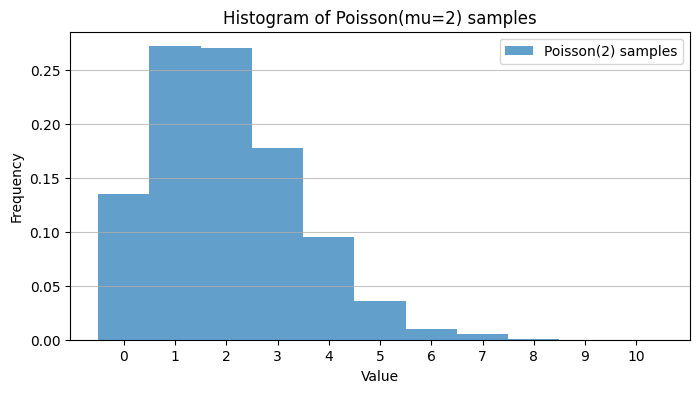

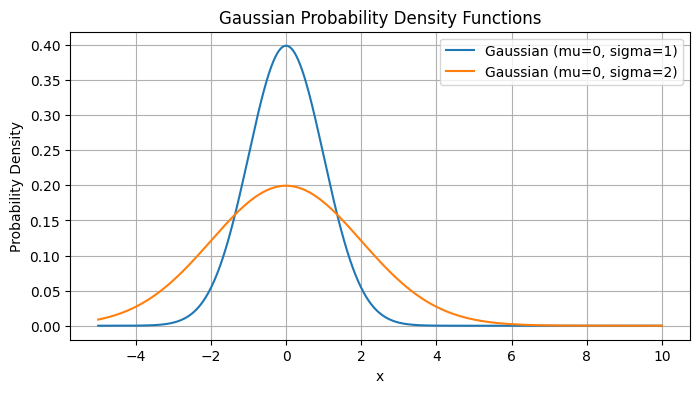

In [24]:
# 1. Poisson(mu=2) samples + mean
pois_samples = stats.poisson(mu=2).rvs(size=10_000)
print('Poisson(2) mean ~', round(pois_samples.mean(), 3), '(true 2)')

# 2. histogram of the samples  (plt.hist(...))
plt.figure(figsize=(8, 4))
plt.hist(pois_samples, bins=np.arange(pois_samples.max() + 2) - 0.5, density=True, alpha=0.7, label='Poisson(2) samples')
plt.title('Histogram of Poisson(mu=2) samples')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xticks(np.arange(pois_samples.max() + 1))
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-5, 10, 1000)
plt.figure(figsize=(8, 4))
plt.plot(x, stats.norm.pdf(x, loc=0, scale=1), label='Gaussian (mu=0, sigma=1)')
plt.plot(x, stats.norm.pdf(x, loc=0, scale=2), label='Gaussian (mu=0, sigma=2)')
plt.title('Gaussian Probability Density Functions')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.grid(True)
plt.legend()
plt.show()

In [25]:
from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [26]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')


D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [27]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')


0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [29]:
# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)
# hint: a fair n-sided die is [1/n]*n
four_sided_die = [1/4] * 4
six_sided_die = [1/6] * 6

print('Entropy fair 4-sided die:', round(entropy(four_sided_die, base=2), 3), 'bits')
print('Entropy fair 6-sided die:', round(entropy(six_sided_die, base=2), 3), 'bits')

# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3]); Q = np.array([0.5, 0.5])
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')

# 3. Most / least informative iris feature (from 5C)
# From the previous cell (AScHXWGEdvN_), the sorted mutual information scores were:
# 0.990  petal length (cm)
# 0.975  petal width (cm)
# 0.474  sepal length (cm)
# 0.286  sepal width (cm)
Most_informative = 'petal length (cm)'
Least_informative = 'sepal width (cm)'

print(f'Most informative iris feature: {Most_informative}')
print(f'Least informative iris feature: {Least_informative}')

Entropy fair 4-sided die: 2.0 bits
Entropy fair 6-sided die: 2.585 bits
D(P || Q) = 0.119 bits
Most informative iris feature: petal length (cm)
Least informative iris feature: sepal width (cm)
